# 22: Is the Crystal a Thing or a Flow?

The notebook preserves both failures: privileged predictive boundary and privileged outer causal boundary. The surviving result is spatial causal locality, not individuality.


In [1]:
from pathlib import Path
import json
import math
import os
import random
import sys
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / "notebooks" / "_shared"))

from digital_crystal import (
    CrystalParams,
    advance_one_step,
    attachment_probability,
    axial_to_xy,
    cell_keyed_uniform,
    frontier,
    hex_distance,
    initial_state,
    neighbors,
    run_crystal,
)

NOTEBOOK_PROFILE = os.environ.get("NOTEBOOK_PROFILE", "quick")
RUN_CANONICAL = os.environ.get("RUN_CANONICAL", "0") in {"1", "true", "True"}

def load_json(path):
    return json.loads((ROOT / path).read_text(encoding="utf-8"))

def mean_of(summary, key="mean"):
    return summary[key] if isinstance(summary, dict) and key in summary else summary

def audit(label, observed, source="canonical research artifact"):
    return {"label": label, "source": source, "observed": observed}

def plot_cells(ax, occupied, lost=None, selected=None, title=""):
    lost = lost or set()
    selected = selected or set()
    for cells, color, size, alpha in [(occupied, "#253494", 18, .85), (lost, "#b2182b", 30, .9), (selected, "#fdae61", 45, .95)]:
        if cells:
            xy = np.array([axial_to_xy(c) for c in cells])
            ax.scatter(xy[:,0], xy[:,1], s=size, c=color, alpha=alpha)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(title)


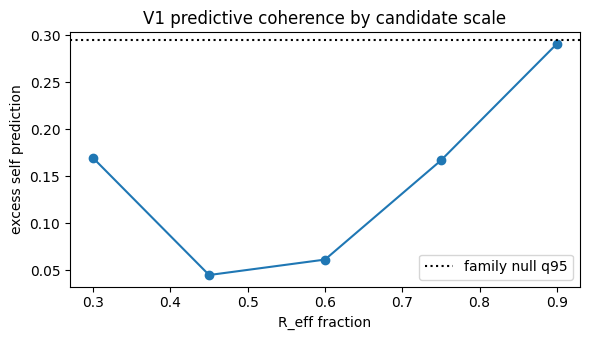

{'label': 'V1 predictive boundary',
 'source': 'canonical research artifact',
 'observed': {'best_scale': 0.9,
  'family_max': 0.29057193806712067,
  'family_p': 0.08491508491508491,
  'status': 'FAILED',
  'audit_problems': ['centered geometry',
   'non-identical environments',
   'future extent contamination',
   'scrambled region temporal identity']}}

In [2]:
v1obs = load_json("research/digital-life/ch22-predictive-coherence-v1/stage-02-observed-family.json")
v1null = load_json("research/digital-life/ch22-predictive-coherence-v1/stage-03-family-null.json")
v1 = load_json("research/digital-life/ch22-predictive-coherence-v1/stage-04-verdict.json")
scales = [row["radius_fraction"] for row in v1obs["by_scale"]]
excess = [row["excess_predictive_coherence"] for row in v1obs["by_scale"]]
fig, ax = plt.subplots(figsize=(6,3.5))
ax.plot(scales, excess, marker="o"); ax.axhline(v1null["null_q95_family_max"], color="black", ls=":", label="family null q95")
ax.set(title="V1 predictive coherence by candidate scale", xlabel="R_eff fraction", ylabel="excess self prediction"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "ch22-v1-predictive-coherence-audit.png", bbox_inches="tight"); plt.show()
audit("V1 predictive boundary", {
    "best_scale": v1["best_scale_radius_fraction"],
    "family_max": v1["family_max_excess_predictive_coherence"],
    "family_p": v1["family_permutation_p_value"],
    "status": v1["status"],
    "audit_problems": ["centered geometry", "non-identical environments", "future extent contamination", "scrambled region temporal identity"],
}, source="canonical research artifact")


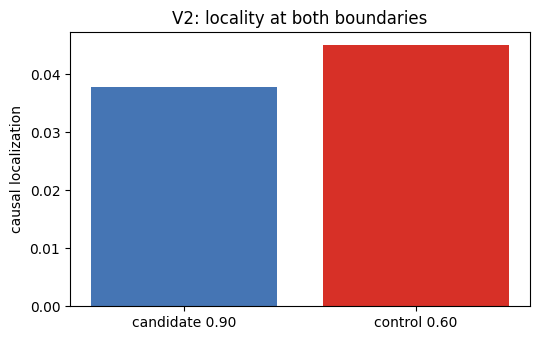

{'label': 'V2 causal boundary',
 'source': 'canonical research artifact',
 'observed': {'requested_groups': 96,
  'usable_groups': 25,
  'usable_fraction': 0.2604166666666667,
  'candidate_localization': 0.03772178756967181,
  'control_localization': 0.04496537516143774,
  'candidate_minus_control': -0.007243587591765921,
  'p_greater': 0.9692576855786054,
  'status': 'FAILED'}}

In [3]:
ds = load_json("research/digital-life/ch22-causal-boundary-coherence-v2/stage-01-intervention-dataset.json")
coh = load_json("research/digital-life/ch22-causal-boundary-coherence-v2/stage-02-causal-coherence.json")
v2 = load_json("research/digital-life/ch22-causal-boundary-coherence-v2/stage-03-verdict.json")
labels = ["candidate 0.90", "control 0.60"]
vals = [coh["candidate_causal_localization"]["mean"], coh["control_causal_localization"]["mean"]]
fig, ax = plt.subplots(figsize=(5.5,3.5))
ax.bar(labels, vals, color=["#4575b4", "#d73027"]); ax.set(ylabel="causal localization", title="V2: locality at both boundaries")
fig.tight_layout(); fig.savefig(FIG_DIR / "ch22-v2-causal-locality-audit.png", bbox_inches="tight"); plt.show()
audit("V2 causal boundary", {
    "requested_groups": ds["requested_groups"],
    "usable_groups": ds["usable_groups"],
    "usable_fraction": ds["usable_fraction"],
    "candidate_localization": vals[0],
    "control_localization": vals[1],
    "candidate_minus_control": coh["candidate_minus_control_excess"]["mean"],
    "p_greater": coh["paired_signflip_test"]["p_value"],
    "status": v2["status"],
}, source="canonical research artifact")


## Bounded claim

The privileged boundary hypotheses failed. Spatial causal locality survives, but it does not establish an individual, self, autonomous entity, or causal closure. The object is better treated here as a dynamically generated active interface or process field.

## Provenance

Current local book chapter: `content/books/digital-life/22-is-the-crystal-a-thing-or-a-flow/index.md` (local working tree authority)

Research scripts: `ch22_digital_crystal_predictive_coherence_v1.py`, `ch22_digital_crystal_causal_boundary_coherence_v2.py`

Canonical artifacts: `research/digital-life/ch22-predictive-coherence-v1/`, `research/digital-life/ch22-causal-boundary-coherence-v2/`

Notebook figures: `ch22-v1-predictive-coherence-audit.png`, `ch22-v2-causal-locality-audit.png`

Execution mode: canonical-artifact-audit

## Claim Ledger

FAILED: V1 privileged predictive boundary; V2 privileged outer causal boundary.

SUPPORTED: spatial causal locality measured at both candidate and pseudo-boundaries.

UNTESTED: individuality, selfhood, autonomy, causal closure.
